In [1]:
from google.colab import drive
import os
import tensorflow as tf
import matplotlib.pyplot as pp
import numpy as np
import seaborn as sns
import math
import pandas as pd
from tensorflow.keras import models,layers
from sklearn.metrics import confusion_matrix, classification_report,roc_curve, auc,accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
PATH = "/content/drive/MyDrive/Final_Project_AAI_540/"

for c in os.listdir(PATH):
  c_dir = os.path.join(PATH,c)
  count = len(os.listdir(c_dir))
  print(f"Number of images for class{c} : {count}")

Number of images for classGray_Leaf_Spot : 574
Number of images for classBlight : 1146
Number of images for classCommon_Rust : 1306
Number of images for classHealthy : 1162


In [4]:
#Lets define some standard constants that we will use across our model
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=40

In [6]:
#Our raw dataset which we will use across the notebook
#Will be split across training and validation later
train_ds = tf.keras.utils.image_dataset_from_directory(
    PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Y_names=train_ds.class_names

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


Found 4188 files belonging to 4 classes.
Using 3351 files for training.
Found 4188 files belonging to 4 classes.
Using 837 files for validation.


yay
                Y  Count
0          Blight    924
1     Common_Rust   1058
2  Gray_Leaf_Spot    452
3         Healthy    917


/tmp/ipykernel_11210/2763941875.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Y', x='Count', data=temp, palette='muted')


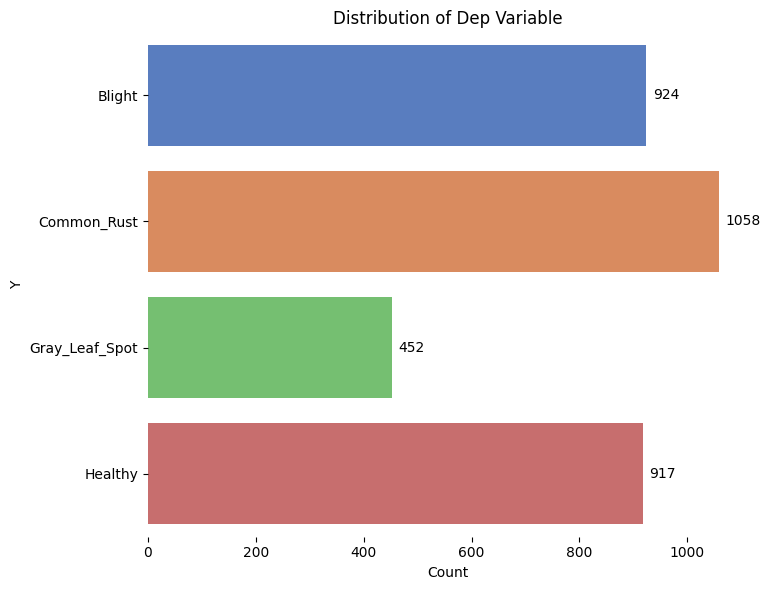

In [7]:
#Looking at class distribution to see if rebalancing is warranted.
dict1 = {}
for images, labels in train_ds.as_numpy_iterator():
    for label in labels:
        Y_label = Y_names[label]
        if Y_label in dict1:
            dict1[Y_label] += 1
        else:
            dict1[Y_label] = 1
print("yay")
counts = [dict1.get(Y_name, 0) for Y_name in Y_names]

temp = pd.DataFrame({'Y': Y_names,'Count': counts})
print(temp)
# Plotting
pp.figure(figsize=(14, 6))

pp.subplot(1, 2, 1)
sns.barplot(y='Y', x='Count', data=temp, palette='muted')
pp.title('Distribution of Dep Variable')
pp.xlabel('Count')
pp.ylabel('Y')
ax = pp.gca()
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', (width, p.get_y() + p.get_height() / 2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')
sns.despine(left=True, bottom=True)

pp.tight_layout()
pp.show()

In [8]:
#Lets look at pixel values for each class and if we can identify any trends.

def pixels(dataset, Y_names):
    dict2 = {name: [] for name in Y_names}


    for images, labels in dataset.as_numpy_iterator():
        for image, label in zip(images, labels):
            Y_label = Y_names[label]
            dict2[Y_label].append(image.flatten())


    stats = {}
    for Y_name, pixels in dict2.items():
        pixels = np.concatenate(pixels)
        mean = np.mean(pixels)
        std = np.std(pixels)
        stats[Y_name] = (mean, std)

    return stats


stats = pixels(train_ds, Y_names)
for Y_name, stats in stats.items():
    print(f"{Y_name} - Mean: {stats[0]}, Std Dev: {stats[1]}")

Blight - Mean: 110.65773010253906, Std Dev: 42.46098327636719
Common_Rust - Mean: 86.35395050048828, Std Dev: 64.97688293457031
Gray_Leaf_Spot - Mean: 111.86962127685547, Std Dev: 46.37336349487305
Healthy - Mean: 136.5504608154297, Std Dev: 50.166717529296875


In [9]:
#Just to remind ourselves with the tensorflow dataset we creates, lets take one sample batch and corresponding Y and print the shape and list respectively
XB, YB = next(iter(train_ds))
print(XB.shape)
print(YB.numpy())

(32, 256, 256, 3)
[3 0 3 1 2 0 2 0 3 0 0 3 2 2 3 3 2 3 1 3 1 1 0 3 1 3 0 3 2 3 3 1]


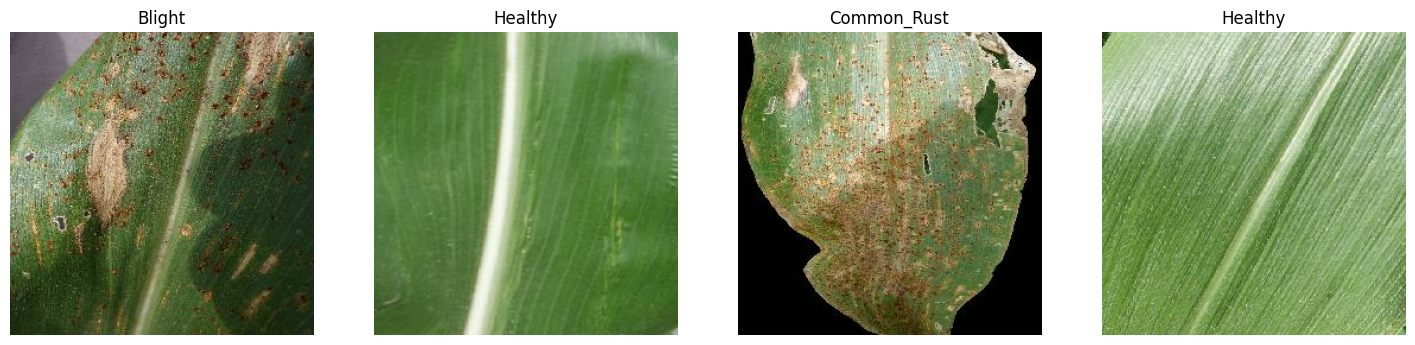

In [10]:
#Lets display an image sample of each class to see what we can expect
c = 1
pp.figure(figsize=(18,10))
for i in [1,2,3,15]:  #index counted and taken from output of above cell, a quick workaround to get one sample of each class
    ax = pp.subplot(1, 4, c)
    pp.imshow(XB[i].numpy().astype("uint8"))
    pp.title(Y_names[YB[i]])
    pp.axis("off")
    c = c + 1
pp.show()

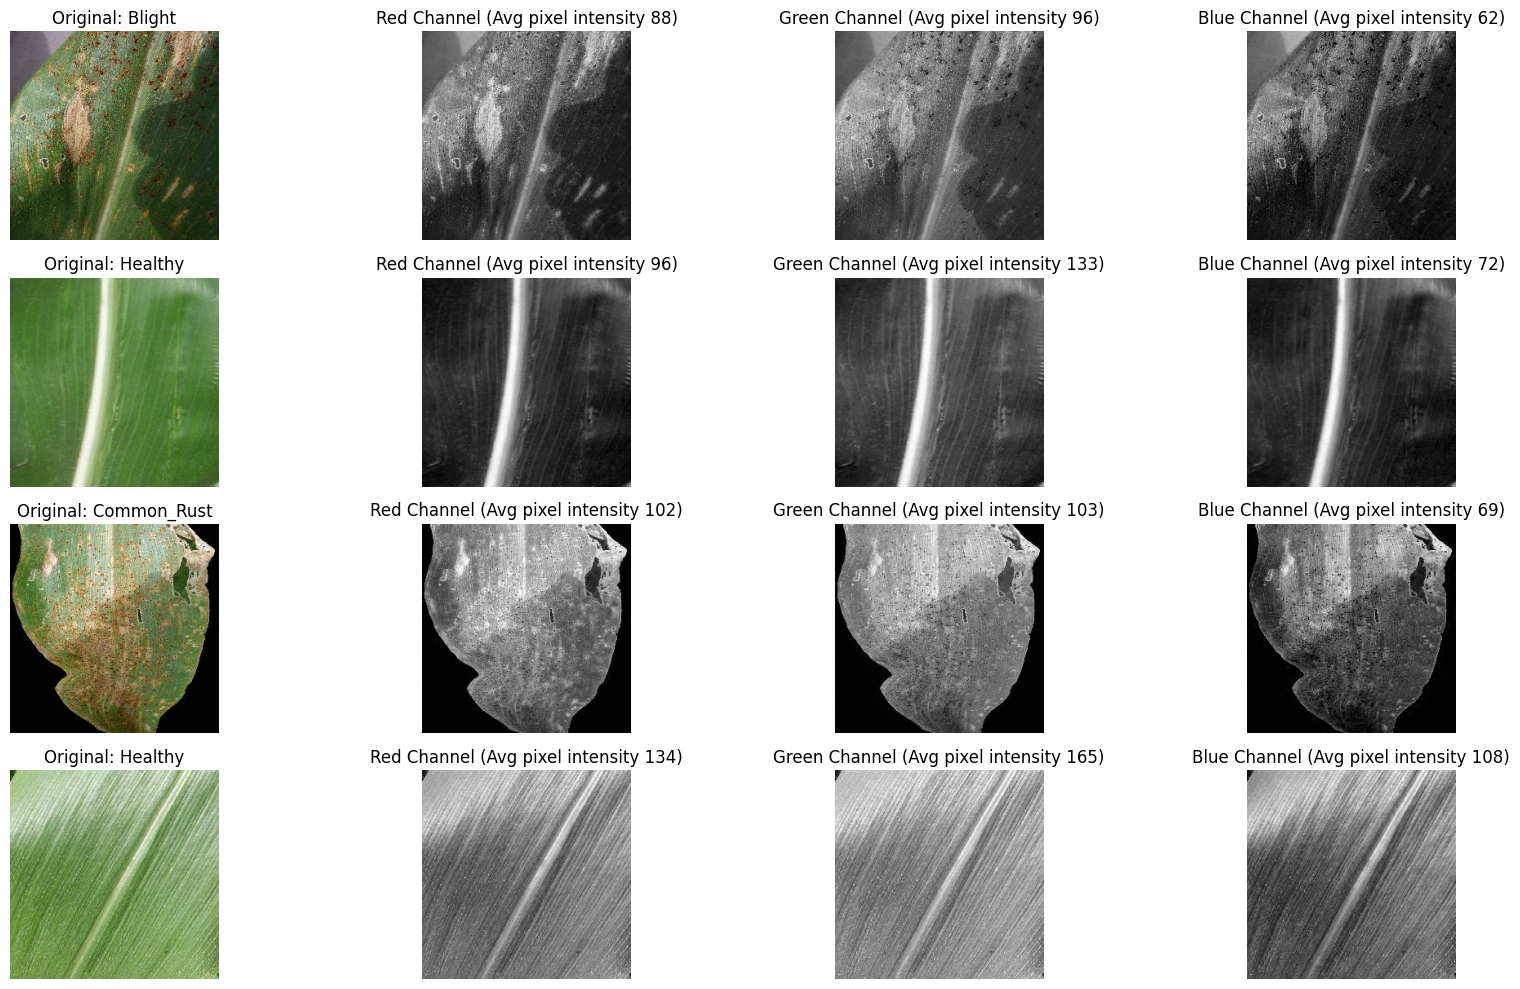

In [11]:
#Another analysis that we can look to do is color channel partitioning
#Since healthy images primarily would have more G of GRB than diseased images and diseased images would have more R of RGB since pigmentation would be more so in the red channel than blue or green.
c = 0
pp.figure(figsize=(18,10))
for i in [1,2,3,15]:
  image = XB[i]

  red_channel = image[:, :, 0]
  green_channel = image[:, :, 1]
  blue_channel = image[:, :, 2]

  red_mean = math.floor(tf.reduce_mean(red_channel).numpy())
  green_mean = math.floor(tf.reduce_mean(green_channel).numpy())
  blue_mean = math.floor(tf.reduce_mean(blue_channel).numpy())

  pp.subplot(4, 4, c*4 + 1)
  pp.imshow(image.numpy().astype("uint8"))
  pp.title(f"Original: {Y_names[YB[i]]}")
  pp.axis("off")


  pp.subplot(4, 4, c*4 + 2)
  pp.imshow(red_channel, cmap="gray")
  pp.title(f"Red Channel (Avg pixel intensity {red_mean})")
  pp.axis("off")


  pp.subplot(4, 4, c*4 + 3)
  pp.imshow(green_channel, cmap="gray")
  pp.title(f"Green Channel (Avg pixel intensity {green_mean})")
  pp.axis("off")


  pp.subplot(4, 4, c*4 + 4)
  pp.imshow(blue_channel, cmap="gray")
  pp.title(f"Blue Channel (Avg pixel intensity {blue_mean})")
  pp.axis("off")

  c = c + 1

# Show the plot
pp.tight_layout()
pp.show()

In [12]:
print(len(train_ds)) #Total batches we have

105


yay
                Y  Count
0          Blight    222
1     Common_Rust    248
2  Gray_Leaf_Spot    122
3         Healthy    245


/tmp/ipykernel_11210/853376671.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Y', x='Count', data=temp, palette='muted')


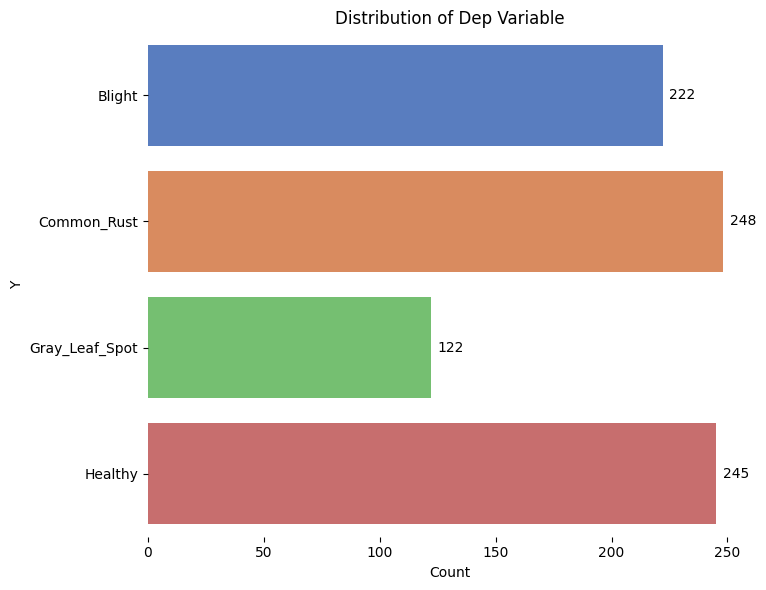

In [13]:
#validation dataset
dict1 = {}
for images, labels in val_ds.as_numpy_iterator():
    for label in labels:
        Y_label = Y_names[label]
        if Y_label in dict1:
            dict1[Y_label] += 1
        else:
            dict1[Y_label] = 1
print("yay")
counts = [dict1.get(Y_name, 0) for Y_name in Y_names]

temp = pd.DataFrame({'Y': Y_names,'Count': counts})
print(temp)
# Plotting
pp.figure(figsize=(14, 6))

pp.subplot(1, 2, 1)
sns.barplot(y='Y', x='Count', data=temp, palette='muted')
pp.title('Distribution of Dep Variable')
pp.xlabel('Count')
pp.ylabel('Y')
ax = pp.gca()
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', (width, p.get_y() + p.get_height() / 2),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')
sns.despine(left=True, bottom=True)

pp.tight_layout()
pp.show()

In [14]:
resize_and_rescale = tf.keras.Sequential([
  tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  tf.keras.layers.Rescaling(1.0/255)
])

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

In [15]:
n_classes = 4


model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),

    resize_and_rescale,
    data_augmentation,


    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),


    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

In [16]:
#Visualizing model structure
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,756 (979.52 KB)

 Trainable params: 250,052 (976.77 KB)

 Non-trainable params: 704 (2.75 KB)

In [21]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    verbose=1
)

# Add ModelCheckpoint to callbacks
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]



In [22]:
# Extract labels for batched dataset
y_train = []
for _, y in train_ds.unbatch():
    y_train.append(y.numpy().item())
y_train = np.array(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=['accuracy'])

In [23]:
hist = model.fit(train_ds,epochs=EPOCHS,batch_size=BATCH_SIZE,verbose=1,class_weight = class_weights,validation_data=val_ds,callbacks=callbacks)

Epoch 1/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 161ms/step - accuracy: 0.9484 - loss: 0.1390 - val_accuracy: 0.8734 - val_loss: 0.3357 - learning_rate: 0.0010
Epoch 2/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 165ms/step - accuracy: 0.9484 - loss: 0.1430 - val_accuracy: 0.8937 - val_loss: 0.2935 - learning_rate: 0.0010
Epoch 3/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 162ms/step - accuracy: 0.9523 - loss: 0.1424 - val_accuracy: 0.7455 - val_loss: 1.0921 - learning_rate: 0.0010
Epoch 4/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.9505 - loss: 0.1410 - val_accuracy: 0.6404 - val_loss: 1.1042 - learning_rate: 0.0010
Epoch 5/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9527 - loss: 0.1357
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 161ms/step - accuracy: 0.9481 - loss: 0.1486 - val_accuracy: 0.7360 - val_loss: 0.8959 - learning_rate: 0.0010
Epoch 6/40
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.95

In [24]:
train_eval = model.evaluate(train_ds, verbose=0)
print("Train eval:", train_eval)

val_eval = model.evaluate(val_ds, verbose=0)
print("Val eval:", val_eval)
#model = tf.keras.models.load_model("/content/Model_V1.keras")

Train eval: [0.09270104020833969, 0.9653834700584412]
Val eval: [0.19996152818202972, 0.9366785883903503]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━

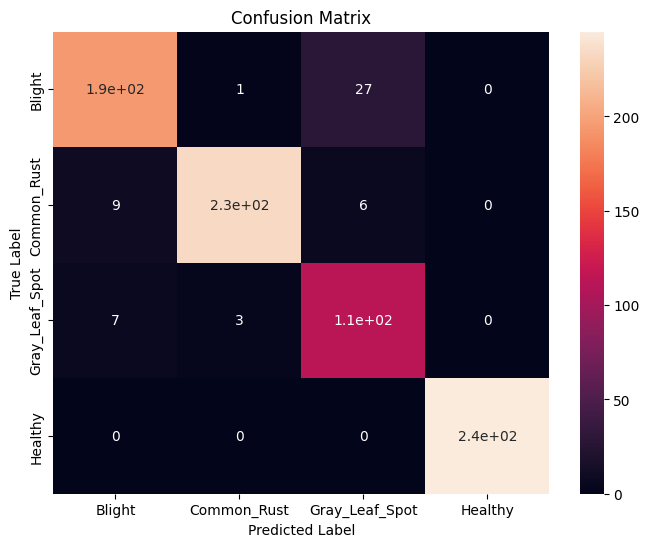


Classification Report:
                precision    recall  f1-score   support

        Blight       0.92      0.87      0.90       222
   Common_Rust       0.98      0.94      0.96       248
Gray_Leaf_Spot       0.77      0.92      0.84       122
       Healthy       1.00      1.00      1.00       245

      accuracy                           0.94       837
     macro avg       0.92      0.93      0.92       837
  weighted avg       0.94      0.94      0.94       837



In [25]:
# Confusion Matrix
y_test = []
y_pred = []
for images, labels in val_ds:
    y_test.extend(labels.numpy())
    y_pred.extend(np.argmax(model.predict(images), axis=1))

cm = confusion_matrix(y_test, y_pred)

pp.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,xticklabels=Y_names,yticklabels=Y_names)

pp.title('Confusion Matrix')
pp.xlabel('Predicted Label')
pp.ylabel('True Label')

pp.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test,y_pred,target_names=Y_names))

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


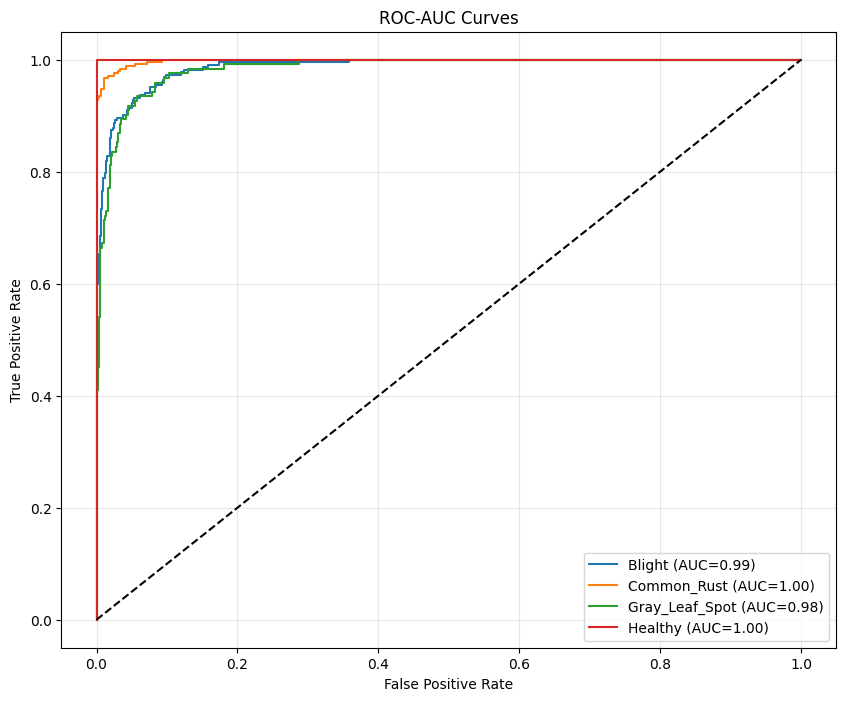

In [26]:
#ROC-AUC curve, plotting curves of individual classes
y_pred_proba = model.predict(val_ds)
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])

pp.figure(figsize=(10,8))

for i in range(len(Y_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    pp.plot(fpr, tpr, label=f'{Y_names[i]} (AUC={roc_auc:.2f})')

pp.plot([0,1], [0,1], 'k--')
pp.xlabel('False Positive Rate')
pp.ylabel('True Positive Rate')
pp.title('ROC-AUC Curves')
pp.legend()
pp.grid(alpha=0.3)
pp.show()

In [27]:
#End of Model EDA and training. After this, we will move to MLOps and model CI/DI
model.save("/content/drive/MyDrive/Final_Project_AAI_540/Model_V1.0.keras")